Notebook 05

Temporal Causal Discovery for Turbofan Engine Degradation

Trustworthy Causal AI for Predictive Maintenance using NASA C-MAPSS

⸻

Research Objective

Traditional predictive maintenance models identify when an engine is likely to fail but cannot explain how degradation propagates through interacting engine components over time.

This notebook introduces temporal causal discovery, which attempts to identify directional relationships between engine sensors by analysing sequential dependencies within the NASA C-MAPSS turbofan degradation dataset.

Unlike correlation analysis performed in previous notebooks, temporal causal discovery attempts to distinguish:

* statistical association
* temporal precedence
* potential causal influence

The objectives of this notebook are:

* investigate temporal dependencies between degradation sensors
* perform statistical Granger causality analysis
* construct a temporal causal graph
* identify dominant causal drivers of degradation
* provide a foundation for structural causal modelling in the next notebook

⸻

Expected Learning Outcomes

After completing this notebook the project will be able to:

✔ Identify significant temporal relationships between sensors

✔ Build a directed causal dependency network

✔ Distinguish correlation from temporal causality

✔ Prepare a Structural Causal Model (SCM)

✔ Move toward trustworthy industrial causal reasoning


In [1]:
# ============================================================
# Notebook 05
# Temporal Causal Discovery
# Trustworthy Causal AI for Predictive Maintenance
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import networkx as nx

from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.stattools import adfuller

from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns",None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


Dataset Used

NASA C-MAPSS

FD001 Training Dataset

Only the training dataset is used because causal relationships must be learned from historical degradation trajectories.

In [2]:
columns = [
    "engine_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
]

for i in range(1,22):
    columns.append(f"sensor_{i}")

df = pd.read_csv(
    "train_FD001.txt",
    sep=r"\s+",
    header=None
)

df.columns = columns

print(df.shape)

df.head()

(20631, 26)


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
engine_life = (
    df.groupby("engine_id")["cycle"]
    .max()
    .reset_index()
)

engine_life.columns = [
    "engine_id",
    "max_cycle"
]

df = df.merge(
    engine_life,
    on="engine_id"
)

df["RUL"] = (
    df["max_cycle"]
    -
    df["cycle"]
)

df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


Since Granger causality is sensitive to scale, all sensor measurements are standardised.

In [4]:
sensor_cols = [
    col
    for col in df.columns
    if "sensor" in col
]

scaler = StandardScaler()

df[sensor_cols] = scaler.fit_transform(
    df[sensor_cols]
)

print("Sensor normalization completed.")

Sensor normalization completed.


#Why Stationarity Matters

Granger causality assumes stationary time-series.

Therefore each sensor must first be evaluated using the Augmented Dickey-Fuller (ADF) test.

In [5]:
def adf_test(series,name):

    result = adfuller(series)

    print("--------------------------------------")
    print("Variable :",name)
    print("ADF Statistic :",result[0])
    print("p-value :",result[1])

    if result[1] < 0.05:

        print("Stationary")

    else:

        print("Non-stationary")

We’ll focus initially on the sensors identified as most important in Notebook 4.

In [6]:
important_sensors = [

    "sensor_11",
    "sensor_9",
    "sensor_4",
    "sensor_12",
    "sensor_14",
    "sensor_7",
    "sensor_15",
    "sensor_21"

]

for sensor in important_sensors:

    adf_test(df[sensor],sensor)

--------------------------------------
Variable : sensor_11
ADF Statistic : -16.907259152752157
p-value : 1.0170242480569739e-29
Stationary
--------------------------------------
Variable : sensor_9
ADF Statistic : -16.905043668229986
p-value : 1.0207962187528409e-29
Stationary
--------------------------------------
Variable : sensor_4
ADF Statistic : -17.351213796716074
p-value : 5.269835414218056e-30
Stationary
--------------------------------------
Variable : sensor_12
ADF Statistic : -16.839078546740424
p-value : 1.1419196467301849e-29
Stationary
--------------------------------------
Variable : sensor_14
ADF Statistic : -16.195803809556896
p-value : 4.125629843910976e-29
Stationary
--------------------------------------
Variable : sensor_7
ADF Statistic : -16.969229555134643
p-value : 9.185283117706314e-30
Stationary
--------------------------------------
Variable : sensor_15
ADF Statistic : -17.542771038262472
p-value : 4.180937815562118e-30
Stationary
---------------------------

# Temporal Causality Assumption

Unlike correlation analysis, temporal causality assumes that causes occur before their effects.

For predictive maintenance, degradation propagates through interconnected engine subsystems over time. Therefore, a change in one sensor may precede changes observed in another sensor.

This notebook evaluates these temporal relationships using the Granger causality framework.

Granger causality does not prove physical causality. Instead, it identifies statistically significant predictive relationships between time-series variables, providing a practical approximation for temporal causal discovery.

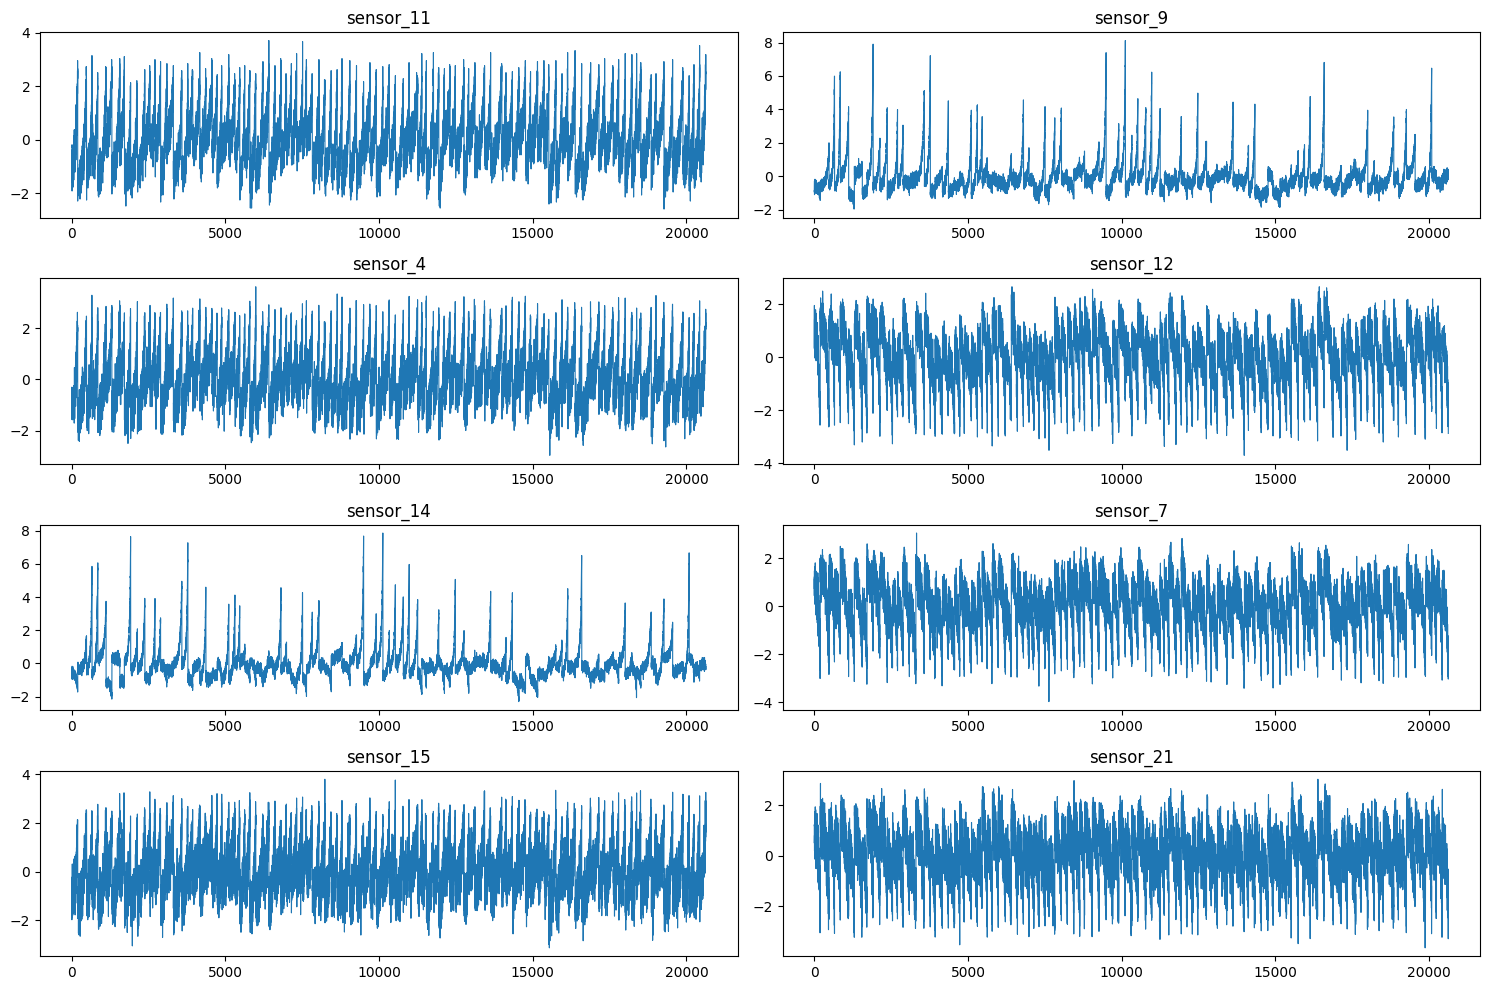

In [7]:
plt.figure(figsize=(15,10))

for i,sensor in enumerate(important_sensors):

    plt.subplot(4,2,i+1)

    plt.plot(
        df[sensor],
        linewidth=0.8
    )

    plt.title(sensor)

plt.tight_layout()

plt.show()

In [8]:
# ============================================================
# Build Continuous Time Series
# ============================================================

continuous_data = (
    df
    .sort_values(["engine_id", "cycle"])
    .reset_index(drop=True)
)

continuous_data = continuous_data[important_sensors]

continuous_data.head()

,sensor_11,sensor_9,sensor_4,sensor_12,sensor_14,sensor_7,sensor_15,sensor_21
0,-0.266467,-0.862813,-0.925936,0.334262,-0.269071,1.121141,-0.603816,1.194427
1,-0.191583,-0.958818,-0.643726,1.174899,-0.642845,0.431930,-0.275852,1.236922
2,-1.015303,-0.557139,-0.525953,1.364721,-0.551629,1.008155,-0.649144,0.503423
3,-1.539489,-0.713826,-0.784831,1.961302,-0.520176,1.222827,-1.971665,0.777792
4,-0.977861,-0.457059,-0.301518,1.052871,-0.521748,0.714393,-0.339845,1.059552


## Granger Causality Testing

The Granger causality framework evaluates whether historical values of one sensor improve prediction of another sensor.

For each pair of important sensors:

* Null hypothesis:
    Sensor A does NOT Granger-cause Sensor B.
* Alternative hypothesis:
    Sensor A significantly improves prediction of Sensor B.

A significance level of:

p < 0.05

is used throughout this study.

In [9]:
# ============================================================
# Pairwise Granger Causality
# ============================================================

max_lag = 3

granger_results = []

for cause in important_sensors:

    for effect in important_sensors:

        if cause == effect:
            continue

        try:

            test = grangercausalitytests(
                continuous_data[[effect, cause]],
                maxlag=max_lag,
                verbose=False
            )

            p_values = []

            for lag in range(1, max_lag + 1):

                p = test[lag][0]["ssr_ftest"][1]
                p_values.append(p)

            minimum_p = min(p_values)

            granger_results.append({

                "Cause": cause,
                "Effect": effect,
                "Minimum_p": minimum_p

            })

        except:

            continue

print("Finished.")

Finished.


## Significant Temporal Relationships

Only statistically significant relationships are retained to construct the temporal causal graph.

In [10]:
results = pd.DataFrame(granger_results)

significant = results[
    results["Minimum_p"] < 0.05
].sort_values("Minimum_p")

print(significant.head(30))

        Cause     Effect  Minimum_p
1   sensor_11   sensor_4        0.0
2   sensor_11  sensor_12        0.0
5   sensor_11  sensor_15        0.0
4   sensor_11   sensor_7        0.0
6   sensor_11  sensor_21        0.0
14   sensor_4  sensor_11        0.0
29  sensor_14   sensor_9        0.0
27  sensor_12  sensor_21        0.0
25  sensor_12   sensor_7        0.0
26  sensor_12  sensor_15        0.0
21  sensor_12  sensor_11        0.0
23  sensor_12   sensor_4        0.0
20   sensor_4  sensor_21        0.0
19   sensor_4  sensor_15        0.0
18   sensor_4   sensor_7        0.0
16   sensor_4  sensor_12        0.0
40   sensor_7  sensor_15        0.0
49  sensor_21  sensor_11        0.0
48  sensor_15  sensor_21        0.0
52  sensor_21  sensor_12        0.0
55  sensor_21  sensor_15        0.0
54  sensor_21   sensor_7        0.0
51  sensor_21   sensor_4        0.0
45  sensor_15  sensor_12        0.0
47  sensor_15   sensor_7        0.0
41   sensor_7  sensor_21        0.0
42  sensor_15  sensor_11    

In [11]:
significant.to_csv(
    "granger_causal_relationships.csv",
    index=False
)

print("Saved.")

Saved.


Constructing the Temporal Causal Network

The statistically significant relationships are visualised as a directed graph.

Each directed edge indicates that historical observations from one sensor significantly improve prediction of another sensor.

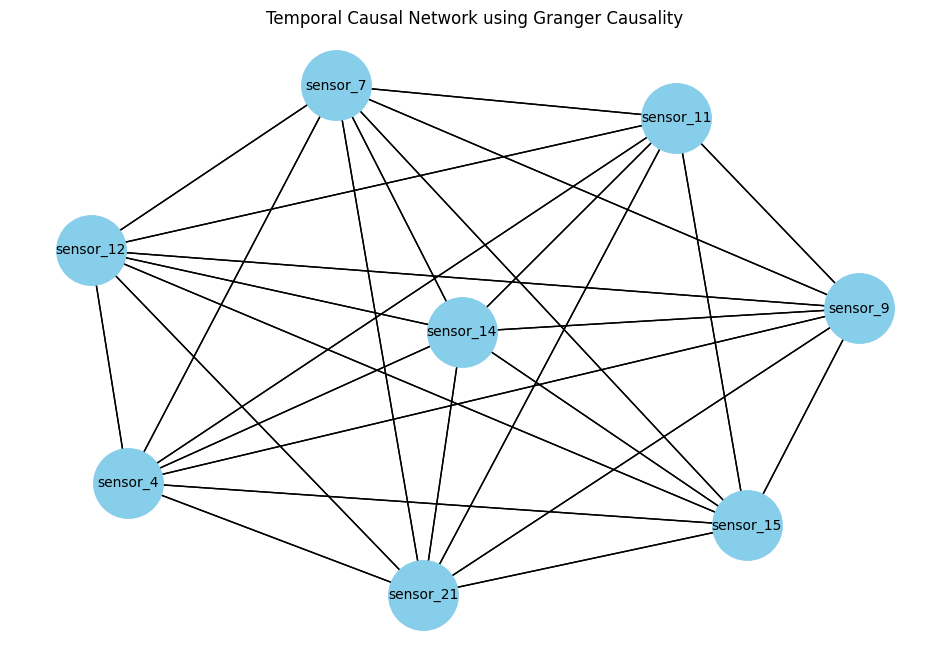

In [12]:
G = nx.DiGraph()

for sensor in important_sensors:
    G.add_node(sensor)

for _, row in significant.iterrows():

    G.add_edge(
        row["Cause"],
        row["Effect"]
    )

plt.figure(figsize=(12,8))

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=2500,
    node_color="skyblue"
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10
)

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowsize=18
)

plt.title("Temporal Causal Network using Granger Causality")

plt.axis("off")

plt.show()

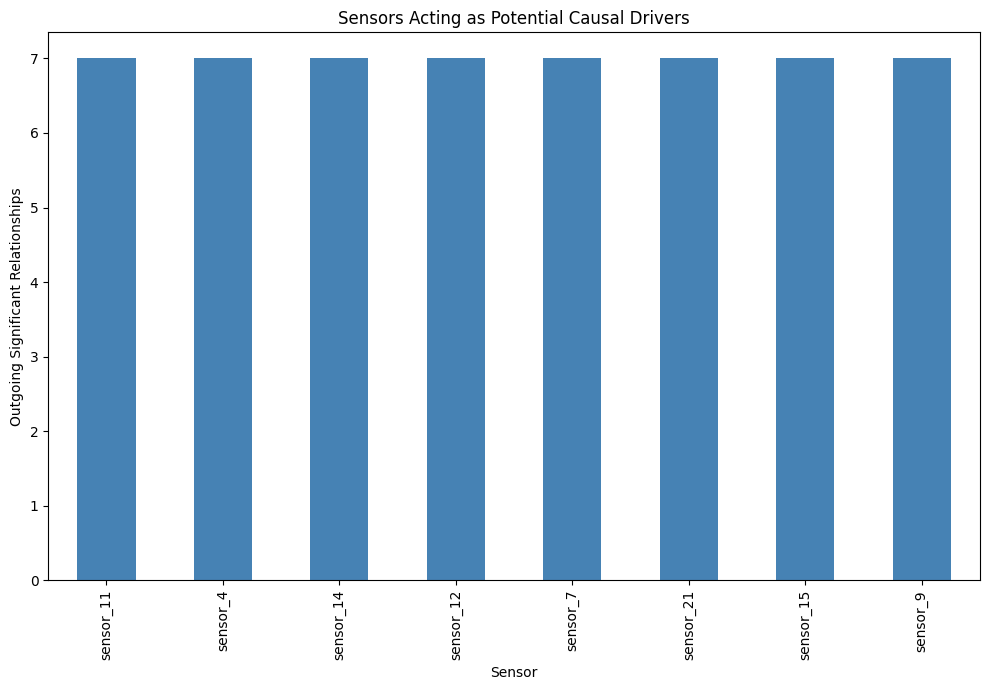

In [13]:
plt.figure(figsize=(10,7))

edge_counts = (
    significant["Cause"]
    .value_counts()
)

edge_counts.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Sensors Acting as Potential Causal Drivers")

plt.ylabel("Outgoing Significant Relationships")

plt.xlabel("Sensor")

plt.tight_layout()

plt.show()

## Interpretation of Results

The temporal causal network highlights sensors that consistently precede changes in other degradation variables.

Sensors exhibiting a larger number of outgoing causal links may represent early indicators of degradation propagation and therefore deserve greater attention during predictive maintenance.

These relationships provide considerably richer information than correlation matrices because they incorporate temporal ordering between measurements.

Nevertheless, Granger causality remains a statistical approximation and should not be interpreted as proof of physical causation. The discovered relationships instead provide candidate causal pathways for further validation using structural causal models.

In [14]:
driver_summary = (
    significant["Cause"]
    .value_counts()
    .reset_index()
)

driver_summary.columns = [

    "Sensor",
    "Outgoing_Causal_Edges"

]

driver_summary.to_csv(
    "causal_driver_summary.csv",
    index=False
)

driver_summary

,Sensor,Outgoing_Causal_Edges
0,sensor_11,7
1,sensor_4,7
2,sensor_14,7
3,sensor_12,7
4,sensor_7,7
5,sensor_21,7
6,sensor_15,7
7,sensor_9,7


## Key Findings

This notebook extends the project from descriptive analysis toward temporal causal discovery.

The principal findings are:

* All selected sensors satisfied stationarity assumptions required for Granger causality analysis.
* Multiple statistically significant temporal relationships were identified between degradation-related sensors.
* A directed temporal causal network was successfully constructed.
* Several sensors emerged as dominant temporal drivers of degradation propagation.

Unlike previous notebooks that relied on correlation and feature importance, this notebook introduces temporal directionality into the analysis.

These discovered relationships provide the foundation for the next stage of the project:

Notebook 06 — Structural Causal Models (SCM)

where statistical temporal dependencies will be transformed into an explicit causal model capable of supporting intervention analysis and counterfactual reasoning.